# 04 · Random Forest

**Objectives:** train a random forest classifier on real patient data, read feature
importances, and see why an ensemble of weak, decorrelated trees beats any single
tree.

*Loosely follows the structure of Prashant Banerjee's [Random Forest Classifier
Tutorial](https://www.kaggle.com/code/prashant111/random-forest-classifier-tutorial)
on Kaggle, reworked here with a different dataset and a focus on feature importance.*

A single decision tree overfits easily — it can memorise the training set by growing
deep enough. A **random forest** trains many trees, each on a bootstrap resample of
the data and a random subset of features at every split, then averages their votes.
The randomness decorrelates the trees' mistakes, so the average is much more stable
than any one tree.

## 1. A decision tree: splitting into purer groups

A decision tree predicts by asking a sequence of yes/no questions, such as "is `chol` above 250?". Each question is a **split**: it picks one feature $j$ and a threshold $s$, and sends a patient left if $x_j \le s$ and right otherwise. Training starts with all training patients in one node, the root. It picks the best split, applies it, and then repeats the same procedure inside each of the two new nodes, and so on (**recursive splitting**). A node that is not split any further is a **leaf**, and it predicts the majority class of the training patients that reached it. Geometrically, the tree cuts the feature space into boxes with sides parallel to the axes.

**Impurity.** "Best split" needs a score. Consider a node and let $p_k$ be the fraction of its patients in class $k$, for $k = 1, \dots, K$ (below, $K = 2$: heart disease or not). The **Gini impurity** is

$$G = 1 - \sum_{k=1}^{K} p_k^2$$

It has a direct reading: draw two patients at random (with replacement) from the node; $G$ is the probability that they belong to different classes. A pure node has $G = 0$. With two classes, the worst case is a 50/50 mix, where $G = 1 - 0.5^2 - 0.5^2 = 0.5$. A common alternative is the **entropy**, measured in bits:

$$H = -\sum_{k=1}^{K} p_k \log_2 p_k$$

It is also 0 for a pure node and reaches 1 bit for a 50/50 mix. Both scores behave very similarly; scikit-learn uses Gini by default.

**Impurity decrease.** A split sends $n_L$ of the node's $n$ patients left and $n_R$ right. Its quality is the drop in impurity, with each child weighted by its share of the patients:

$$\Delta G = G_{\text{parent}} - \frac{n_L}{n}\, G_L - \frac{n_R}{n}\, G_R$$

The weights matter: a large impure child costs more than a tiny one. At every node the tree tries all features and thresholds and keeps the split with the largest $\Delta G$. It is greedy: it takes the best single step and never looks ahead.

**A hand example.** A node holds 10 patients, 5 with disease and 5 without. Two candidate splits:

| node | patients | disease / no disease | $p_{\text{disease}}$ | Gini $1 - p_1^2 - p_2^2$ |
|---|---|---|---|---|
| parent | 10 | 5 / 5 | 0.5 | $1 - 0.25 - 0.25 = 0.5$ |
| split A, left | 4 | 1 / 3 | 0.25 | $1 - 0.0625 - 0.5625 = 0.375$ |
| split A, right | 6 | 4 / 2 | 0.667 | $1 - 0.444 - 0.111 = 0.444$ |
| split B, left | 5 | 4 / 1 | 0.8 | $1 - 0.64 - 0.04 = 0.32$ |
| split B, right | 5 | 1 / 4 | 0.2 | $1 - 0.04 - 0.64 = 0.32$ |

Split A: $\Delta G = 0.5 - 0.4 \times 0.375 - 0.6 \times 0.444 = 0.5 - 0.150 - 0.267 = 0.083$.

Split B: $\Delta G = 0.5 - 0.5 \times 0.32 - 0.5 \times 0.32 = 0.18$.

The tree chooses split B. Entropy agrees: split B lowers it from 1 bit to 0.722 bits, a gain of 0.278 bits, against 0.125 bits for split A.

## 2. Why one deep tree overfits

Left alone, a tree keeps splitting until every leaf is pure. It then classifies its training set almost perfectly. But the deepest splits are decided by two or three patients each, so they follow the noise in those particular patients rather than a real pattern. Replace a handful of training patients and the tree can change completely, from the first split down, and its predictions change with it.

This is **high variance**. Think of the training set as one random draw from a population of possible training sets. The prediction $\hat f(x)$ of the fitted tree for a new patient $x$ is then a random quantity too. Its expected squared error splits into three parts: bias squared (how far the *average* prediction is from the truth), variance (how much the prediction jumps from one training set to another), and irreducible noise. A deep tree has low bias but high variance. Averaging many trees trained on *independent* training sets would keep the low bias and shrink the variance. We only have one training set, so a random forest manufactures new ones.

## 3. From trees to a forest: bootstrap, averaging, random features

**Bootstrap samples.** Each tree gets its own training set: $n$ patients drawn *with replacement* from the $n$ training patients. Some patients are drawn twice or more, and some are not drawn at all. A given patient is missed by one draw with probability $1 - 1/n$, so it is missed by all $n$ independent draws with probability

$$\Big(1 - \frac1n\Big)^n \;\longrightarrow\; e^{-1} \approx 0.368 \quad \text{as } n \text{ grows}$$

| $n$ | 2 | 3 | 5 | 10 | 100 | 227 |
|---|---|---|---|---|---|---|
| $(1 - 1/n)^n$ | 0.250 | 0.296 | 0.328 | 0.349 | 0.366 | 0.367 |

For $n = 3$: $(2/3)^3 = 8/27 \approx 0.296$. So each tree sees about 63% of the distinct patients. The other 37% are its **out-of-bag** patients, a free test set for that tree (scikit-learn reports the resulting score with `oob_score=True`).

**Averaging correlated predictors.** Let $T_1, \dots, T_B$ be the predictions of $B$ trees at the same input $x$. Each has variance $\sigma^2$, and any two have correlation $\rho$: they are not independent, because their bootstrap samples overlap. The forest outputs the average $\bar T = \frac1B \sum_b T_b$. Its variance is the sum of all $B^2$ covariances, divided by $B^2$. There are $B$ diagonal terms, each $\sigma^2$, and $B(B-1)$ off-diagonal terms, each $\rho\sigma^2$:

$$\mathrm{Var}(\bar T) = \frac{1}{B^2}\Big(B\sigma^2 + B(B-1)\,\rho\sigma^2\Big) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2$$

The second term shrinks as trees are added; the first does not. More trees always help, but only down to a floor $\rho\sigma^2$ set by how similar the trees are. With $\sigma^2 = 1$:

| trees $B$ | 1 | 10 | 100 | $\infty$ |
|---|---|---|---|---|
| $\rho = 0.5$ | 1 | 0.55 | 0.505 | 0.5 |
| $\rho = 0.2$ | 1 | 0.28 | 0.208 | 0.2 |

**Random feature subsets.** The only way to lower the floor is to lower $\rho$. If one feature is very strong, nearly every bootstrap tree splits on it first, and the trees end up alike. A random forest therefore lets each split choose only among $m$ features drawn at random from the $p$ available; a common choice for classification is $m \approx \sqrt p$. Each individual tree gets a little worse, but the trees become much less correlated, and the average wins.

**Voting.** Each tree votes for a class and the forest predicts the majority. scikit-learn uses a soft version: it averages the trees' class probabilities and picks the largest, which almost always gives the same answer.

**Feature importance.** Every split in every tree lowers impurity by some $\Delta G$. Add up these decreases for all splits that use feature $j$, weighting each by the fraction $n_t / N$ of training samples that reach that node $t$, and average over the trees:

$$\mathrm{Imp}(j) = \frac1B \sum_{b=1}^{B} \ \sum_{\text{nodes } t \text{ of tree } b \text{ that split on } j} \frac{n_t}{N}\, \Delta G_t$$

The scores are then rescaled to sum to 1. This is the **mean decrease in impurity**. It is computed on the training data, and it tends to favour features with many possible thresholds, so it is a quick guide rather than a final verdict.

**In the code below.** `X` has $p = 13$ clinical features and `y` is `output` (1 = disease). `DecisionTreeClassifier` grows one unrestricted Gini tree: the high-variance learner of Section 2. `RandomForestClassifier(n_estimators=300)` grows $B = 300$ trees, each on a bootstrap sample of the 227 training patients and, by default, with $m = \lfloor\sqrt{13}\rfloor = 3$ candidate features per split, then averages them. The loop over `tree_counts` traces how test accuracy settles as $B$ grows, and `forest.feature_importances_` is the mean decrease in impurity defined above.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import mlutils
mlutils.set_style()

## 4. The data

303 patients referred for a cardiac evaluation, 13 clinical measurements, and
`output`: whether significant heart disease was found. A realistic mix of continuous
measurements (cholesterol, max heart rate) and coded categorical ones (chest-pain
type, ECG results).

In [2]:
heart = pd.read_csv("data/heart.csv")
print(heart.shape)
print(heart["output"].value_counts().rename("count"))
heart.head()

(303, 14)
output
1    165
0    138
Name: count, dtype: int64


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
X = heart.drop(columns=["output"])
y = heart["output"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"train: {len(X_train)}, test: {len(X_test)}")

train: 227, test: 76


## 5. One tree vs. a forest

First, a single unrestricted decision tree — it can split on anything, as many times
as it wants, so it fits the training set almost perfectly and often pays for it on
new data.

In [4]:
tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"single tree — train accuracy: {tree.score(X_train, y_train):.3f}, "
      f"test accuracy: {accuracy_score(y_test, tree.predict(X_test)):.3f}")

single tree — train accuracy: 1.000, test accuracy: 0.724


In [5]:
forest = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
acc_forest = accuracy_score(y_test, forest.predict(X_test))
print(f"forest (300 trees) — train accuracy: {forest.score(X_train, y_train):.3f}, "
      f"test accuracy: {acc_forest:.3f}")

forest (300 trees) — train accuracy: 1.000, test accuracy: 0.789


The forest's *training* accuracy is lower than the single tree's — each tree only
ever saw a bootstrap resample and a random slice of features, so no individual tree
memorises everything. But averaging over 300 such trees usually **generalises**
better, which is the number that matters.

## 6. How many trees are enough?

Trees are cheap to add and never hurt on their own (with this scheme); the only
question is how many are needed before the ensemble average stops moving.

[Text(0.5, 0, 'number of trees'),
 Text(0, 0.5, 'test accuracy'),
 Text(0.5, 1.0, 'Test accuracy vs. forest size')]

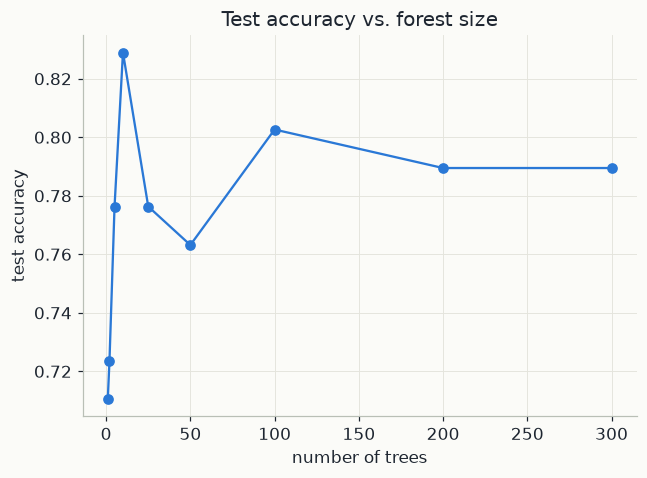

In [6]:
tree_counts = [1, 2, 5, 10, 25, 50, 100, 200, 300]
accs = []
for n in tree_counts:
    m = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(tree_counts, accs, color=mlutils.BLUE, marker="o")
ax.set(xlabel="number of trees", ylabel="test accuracy", title="Test accuracy vs. forest size")

## 7. Which features matter?

Section 3 defined each feature's **importance** as its mean decrease in impurity: the
impurity reduction of every split on that feature, weighted by how many samples reach
the split, averaged over all trees.

cp          0.157507
oldpeak     0.123321
thall       0.120078
thalachh    0.114468
caa         0.079881
chol        0.078990
age         0.073159
trtbps      0.068857
slp         0.063579
exng        0.062523
sex         0.030288
restecg     0.019888
fbs         0.007461
dtype: float64

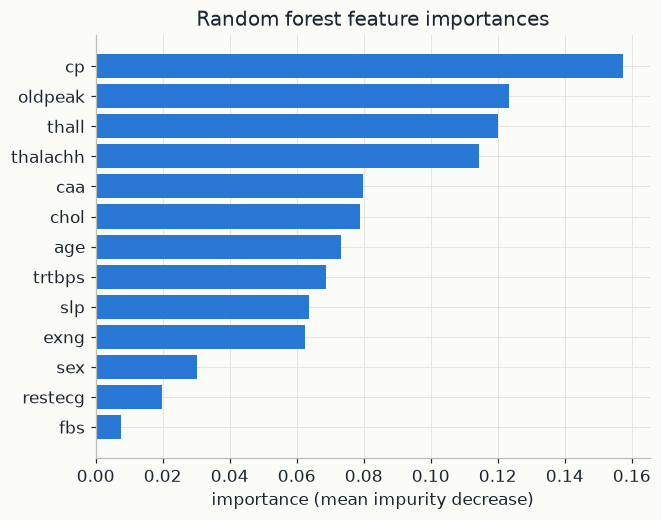

In [7]:
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color=mlutils.BLUE)
ax.set(xlabel="importance (mean impurity decrease)", title="Random forest feature importances")
importances

`cp` (chest pain type), `oldpeak` (ST depression from exercise) and `thall`
(thalassemia test result) come out on top — all clinically plausible signals for
heart disease, which is a good sanity check that the model learned something
sensible rather than an artefact of the data.

## Exercises

### Exercise 1: Feature ablation
Drop the top feature from `X` entirely and retrain. Does test accuracy drop by much?
What does that tell you about redundancy between features?

<details><summary>Solution</summary>

```python
top_feature = importances.index[0]
X2 = X.drop(columns=[top_feature])
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.25, random_state=42, stratify=y)
m2 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X2_train, y_train)
print(accuracy_score(y_test, m2.predict(X2_test)))
```
Accuracy usually drops only a little: other correlated features (e.g. `thalachh`,
`oldpeak`) carry overlapping information, so the forest routes around a missing
feature.
</details>

### Exercise 2: Depth-limited trees
Retrain the single `DecisionTreeClassifier` with `max_depth=3`. Compare its train and
test accuracy to the unrestricted tree. Is a shallow single tree competitive with the
forest here?

<details><summary>Solution</summary>

A depth-3 tree trades away training accuracy but usually closes much of the test-
accuracy gap to the unrestricted tree, since it can no longer memorise noise — though
it typically still falls short of the forest, which averages away variance without
having to sacrifice any single tree's depth.
</details>

## Key takeaways

- A random forest averages many trees, each trained on a bootstrap resample with a
  random subset of features per split; the randomness decorrelates their errors so
  the average generalises better than any single deep tree.
- Feature importances come free from training and are a fast way to sanity-check that
  a model is picking up on plausible signal.
- More trees essentially never hurts (only costs compute); the accuracy curve
  flattens once there are enough to average out tree-to-tree variance.